In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
data=pd.read_csv(r"C:\Users\ISRATUN NAHAR\OneDrive\Desktop\My project\.ipynb_checkpoints\orders (1).csv")
df=pd.DataFrame(data)
print(df) 
print(df.isnull().sum())
print(df.describe())

     order_id customer_id product_id  order_date  quantity payment_method
0      O00001       C0692       P006  2023-01-29         4           Card
1      O00002       C1072       P059  2023-04-19         5           Card
2      O00003       C1187       P030  2024-01-15         1           Card
3      O00004       C0290       P063  2024-01-12         1           Cash
4      O00005       C0094       P032  2024-04-09         2           Card
...       ...         ...        ...         ...       ...            ...
3995   O03996       C1004       P055  2024-03-30         5           Card
3996   O03997       C1008       P014  2024-05-10         4           Card
3997   O03998       C0604       P021  2023-01-30         5         Online
3998   O03999       C0234       P037  2023-07-10         3         Online
3999   O04000       C1182       P071  2023-07-26         2           Card

[4000 rows x 6 columns]
order_id          0
customer_id       0
product_id        0
order_date        0
quantit

In [2]:
#findings

df["order_date"]=pd.to_datetime(df['order_date'])
df["month"]=df["order_date"].dt.to_period("M")
df["year"]=df["order_date"].dt.to_period("Y")
print(df)

     order_id customer_id product_id order_date  quantity payment_method  \
0      O00001       C0692       P006 2023-01-29         4           Card   
1      O00002       C1072       P059 2023-04-19         5           Card   
2      O00003       C1187       P030 2024-01-15         1           Card   
3      O00004       C0290       P063 2024-01-12         1           Cash   
4      O00005       C0094       P032 2024-04-09         2           Card   
...       ...         ...        ...        ...       ...            ...   
3995   O03996       C1004       P055 2024-03-30         5           Card   
3996   O03997       C1008       P014 2024-05-10         4           Card   
3997   O03998       C0604       P021 2023-01-30         5         Online   
3998   O03999       C0234       P037 2023-07-10         3         Online   
3999   O04000       C1182       P071 2023-07-26         2           Card   

        month  year  
0     2023-01  2023  
1     2023-04  2023  
2     2024-01  2024  

In [3]:
avg_orders_per_day=df.groupby("order_date")['order_id'].count().mean()
print(avg_orders_per_day)

7.984031936127744


      month payment_method  order_id
0   2023-01           Card        80
1   2023-01           Cash        84
2   2023-01         Online        82
3   2023-02           Card        94
4   2023-02           Cash        58
5   2023-02         Online        68
6   2023-03           Card        82
7   2023-03           Cash        95
8   2023-03         Online        90
9   2023-04           Card        83
10  2023-04           Cash        75
11  2023-04         Online        70
12  2023-05           Card        74
13  2023-05           Cash        63
14  2023-05         Online        72
15  2023-06           Card        94
16  2023-06           Cash        87
17  2023-06         Online        68
18  2023-07           Card        96
19  2023-07           Cash        94
20  2023-07         Online        70
21  2023-08           Card        90
22  2023-08           Cash        84
23  2023-08         Online        77
24  2023-09           Card        71
25  2023-09           Cash        79
2

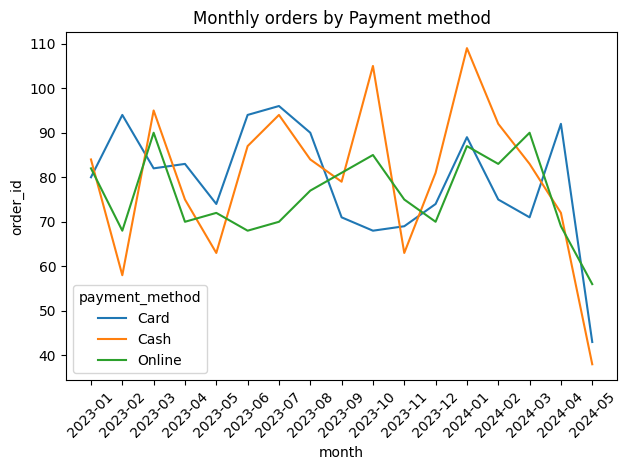

In [4]:
order_per_month=df.groupby(["month","payment_method"])["order_id"].count().reset_index()
print(order_per_month)
order_per_month["month"]=order_per_month["month"].astype(str)
sns.lineplot(data=order_per_month,x="month",y="order_id",markers="o",hue="payment_method")
plt.xticks(rotation=45)
plt.title("Monthly orders by Payment method")
plt.tight_layout()
plt.show()

In [5]:
top_customers=df.groupby("customer_id")["order_id"].count().sort_values(ascending=False)
print(top_customers.head(10))

customer_id
C0291    10
C0460     9
C0642     9
C0588     9
C0552     9
C0795     9
C1133     8
C1120     8
C1165     8
C0094     8
Name: order_id, dtype: int64


In [6]:
product_sales=df.groupby("product_id")["quantity"].sum().sort_values(ascending=False).reset_index(name="total_quantity")
print(product_sales)
order_per_product=df.groupby("product_id")["order_id"].count().sort_values(ascending=False).reset_index(name="purchased")
print(order_per_product)

   product_id  total_quantity
0        P055             201
1        P060             193
2        P018             191
3        P067             178
4        P071             178
..        ...             ...
75       P008             108
76       P045             105
77       P050             104
78       P035              97
79       P075              85

[80 rows x 2 columns]
   product_id  purchased
0        P055         66
1        P018         64
2        P038         62
3        P051         60
4        P065         60
..        ...        ...
75       P035         37
76       P080         37
77       P050         37
78       P045         36
79       P075         32

[80 rows x 2 columns]


payment_method
Cash      1362
Card      1345
Online    1293
Name: count, dtype: int64


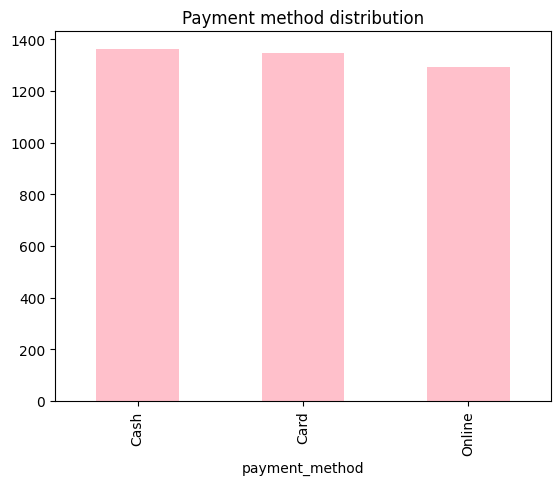

In [7]:
popular_method=df["payment_method"].value_counts()
print(popular_method)
popular_method.plot(kind='bar',color="pink")
plt.title("Payment method distribution")
plt.show()

weekday
Saturday     593
Tuesday      593
Friday       590
Sunday       581
Monday       575
Wednesday    545
Thursday     523
Name: order_id, dtype: int64


Text(0.5, 1.0, 'weekly shopping trend')

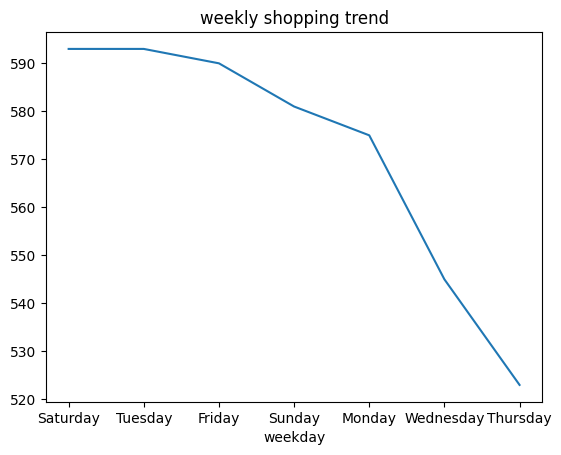

In [14]:
df["weekday"]=df["order_date"].dt.day_name()
peak_day=df.groupby('weekday')['order_id'].count().sort_values(ascending=False)
print(peak_day)
peak_day.plot()
plt.title("weekly shopping trend")


      month  customers
0   2023-01        213
1   2023-02        198
2   2023-03        240
3   2023-04        206
4   2023-05        192
5   2023-06        224
6   2023-07        232
7   2023-08        230
8   2023-09        213
9   2023-10        233
10  2023-11        188
11  2023-12        206
12  2024-01        265
13  2024-02        219
14  2024-03        209
15  2024-04        213
16  2024-05        131


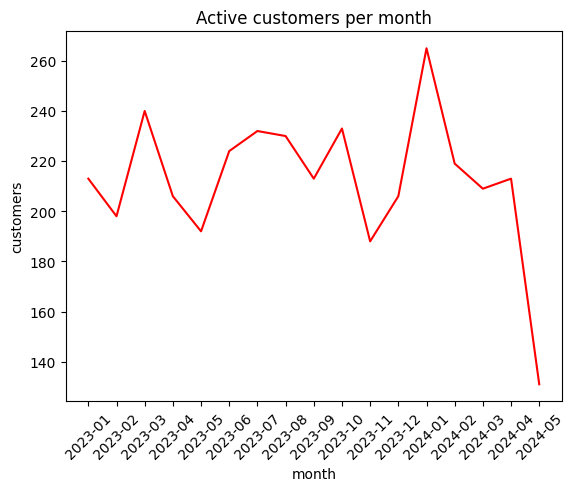

In [29]:
active_customer=df.groupby('month')['customer_id'].nunique().reset_index(name="customers")
active_customer['month'] =active_customer['month'].astype(str)
print(active_customer)
sns.lineplot(data=active_customer,x='month',y='customers',color="red")
plt.title("Active customers per month")
plt.xticks(rotation=45)
plt.show()